In [ ]:
pip install inference-sdk

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-15 at 5.31.13 PM.png to Screenshot 2026-04-15 at 5.31.13 PM (1).png


In [ ]:
IMAGE_PATH = "Screenshot 2026-04-15 at 5.31.13 PM (1).png"

RAW RESULT:
{'inference_id': 'ca61eeb8-7f60-4a71-ae1b-651a19e47f52', 'time': 0.04044599299959373, 'image': {'width': 1268, 'height': 918}, 'predictions': [{'x': 670.0, 'y': 685.0, 'width': 242.0, 'height': 154.0, 'confidence': 0.9507150053977966, 'class': 'text', 'class_id': 0, 'detection_id': '571bd6d0-5425-428c-a2a7-bea0bc46f38e', 'points': [{'x': 764.0, 'y': 612.0}, {'x': 763.0, 'y': 613.0}, {'x': 752.0, 'y': 613.0}, {'x': 751.0, 'y': 614.0}, {'x': 739.0, 'y': 614.0}, {'x': 738.0, 'y': 615.0}, {'x': 731.0, 'y': 615.0}, {'x': 730.0, 'y': 616.0}, {'x': 723.0, 'y': 616.0}, {'x': 722.0, 'y': 617.0}, {'x': 715.0, 'y': 617.0}, {'x': 714.0, 'y': 618.0}, {'x': 707.0, 'y': 618.0}, {'x': 706.0, 'y': 619.0}, {'x': 699.0, 'y': 619.0}, {'x': 698.0, 'y': 620.0}, {'x': 691.0, 'y': 620.0}, {'x': 690.0, 'y': 621.0}, {'x': 686.0, 'y': 621.0}, {'x': 685.0, 'y': 622.0}, {'x': 681.0, 'y': 622.0}, {'x': 680.0, 'y': 623.0}, {'x': 676.0, 'y': 623.0}, {'x': 675.0, 'y': 624.0}, {'x': 671.0, 'y': 624.0}, {'x'

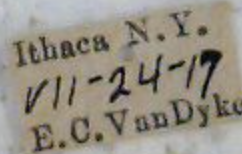


Box 1 | confidence 0.92
TEXT: CASENT
5003907



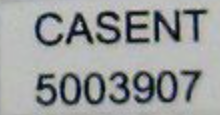

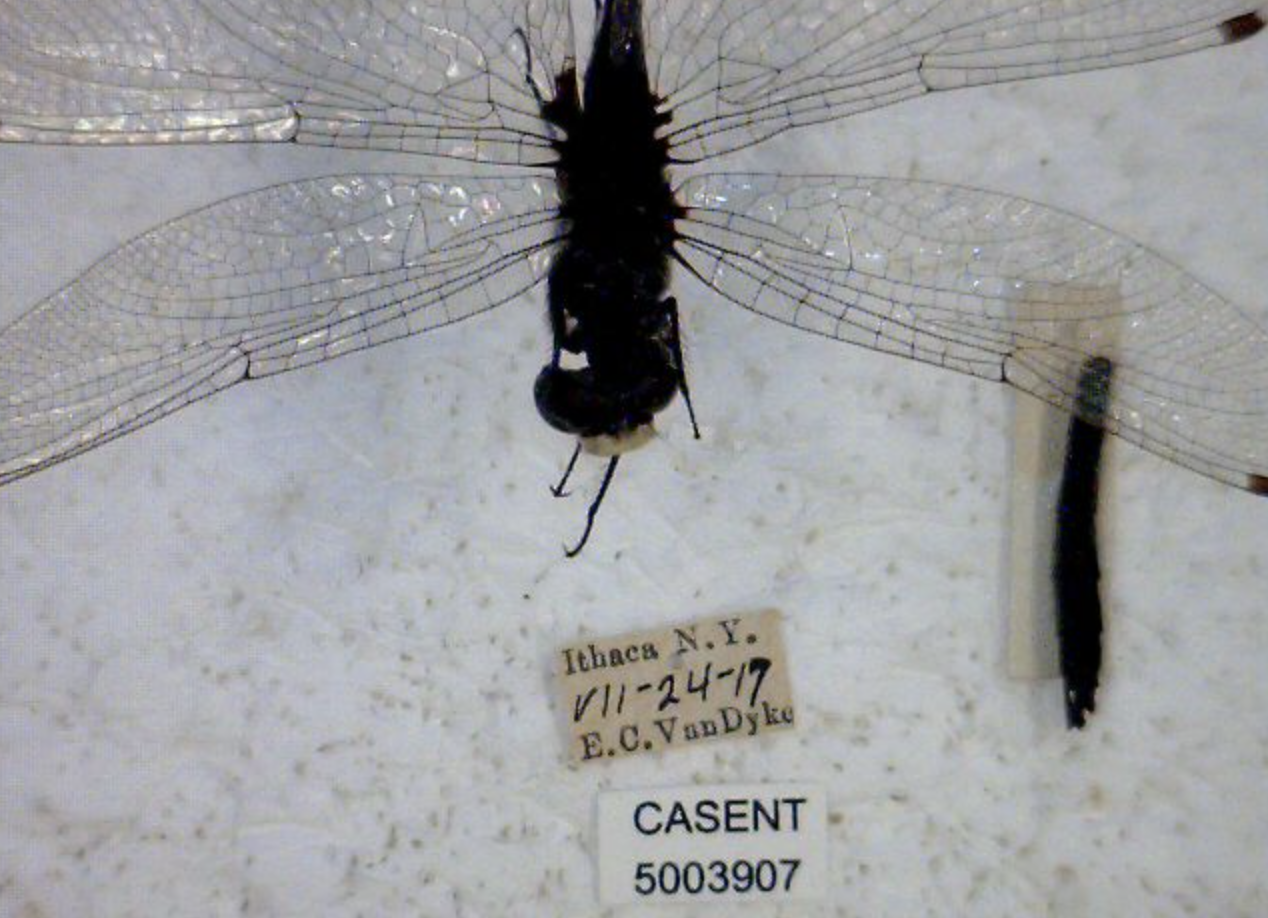

In [ ]:
from inference_sdk import InferenceHTTPClient
import cv2
import pytesseract
from google.colab.patches import cv2_imshow

# Initialize client
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="jwdgcnRIwOz0kPB4Tpto"
)

# Run inference
result = CLIENT.infer(IMAGE_PATH, model_id="entamology/6")

print("RAW RESULT:")
print(result)

# Load image
img = cv2.imread(IMAGE_PATH)

for i, pred in enumerate(result.get("predictions", [])):
    x = int(pred["x"])
    y = int(pred["y"])
    w = int(pred["width"])
    h = int(pred["height"])
    conf = pred["confidence"]

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    crop = img[y1:y2, x1:x2]

    # OCR
    text = pytesseract.image_to_string(crop)

    print(f"\nBox {i} | confidence {conf:.2f}")
    print("TEXT:", text)

    cv2_imshow(crop)

# Save output image
cv2.imwrite("output.jpg", img)

# Show final image (optional)
cv2_imshow(img)